# HTML Report Generation

Every CausalPy experiment can produce a self-contained HTML report that
summarises the analysis: effect estimates, diagnostic plots, and (when
used with the pipeline) sensitivity-check results. The report is ready
to share with stakeholders or embed in a notebook.

In [1]:
import pandas as pd

import causalpy as cp

## Fit an experiment

First we fit an Interrupted Time Series model — the same workflow you
would use without any pipeline.

In [2]:
df = (
    cp.load_data("its")
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .set_index("date")
)
treatment_time = pd.to_datetime("2017-01-01")

seed = 42
model = cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed})

result = cp.InterruptedTimeSeries(
    df,
    treatment_time,
    formula="y ~ 1 + t",
    model=model,
).fit()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


## Generate a report

Call `.generate_report()` on the fitted experiment. The method returns
the HTML as a string and, optionally, writes it to a file.

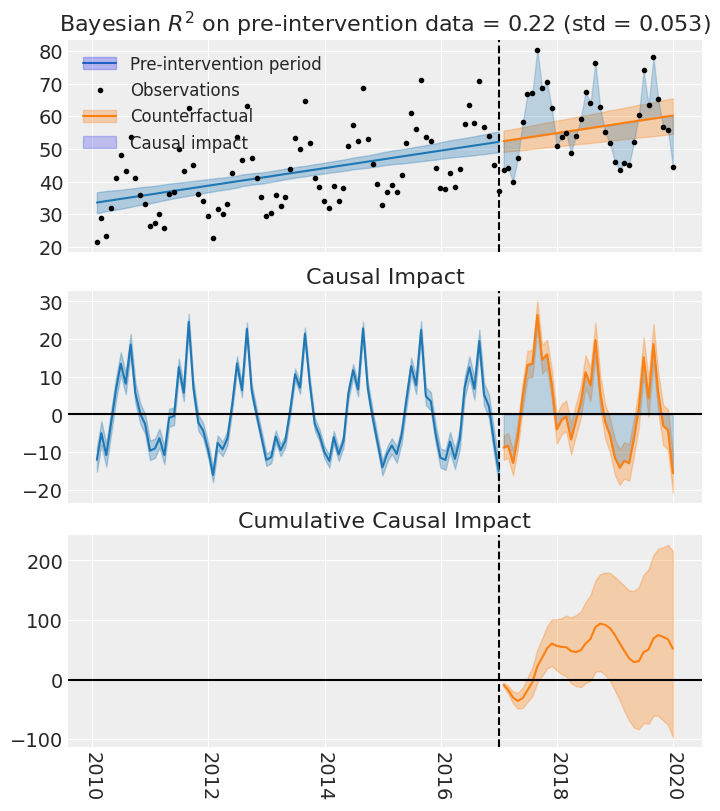

In [3]:
html = result.generate_report()

Which we can preview below:


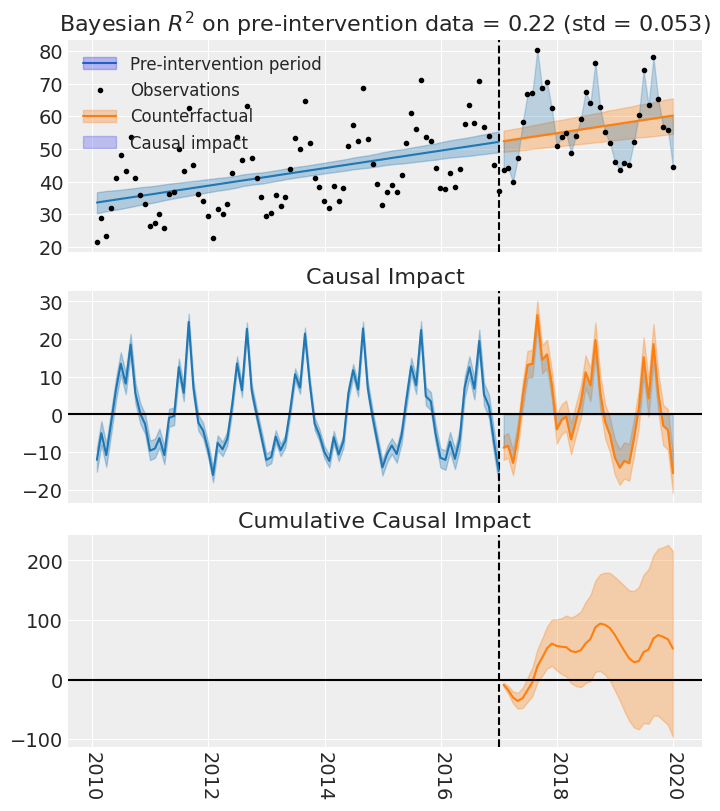

In [4]:
import html as html_module
import warnings

from IPython.display import HTML

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", "Consider using IPython.display.IFrame", UserWarning
    )
    report_widget = HTML(
        '<iframe srcdoc="' + html_module.escape(html) + '" width="100%" height="1000"'
        ' style="border: 1px solid #ddd; border-radius: 6px;"></iframe>'
    )
report_widget

## Report with sensitivity checks

The standalone `generate_report()` covers effect estimates and plots. To
include sensitivity-check results, run the analysis through a
`Pipeline` with a `SensitivityAnalysis` step. The `GenerateReport` step
then bundles everything — effect summary, diagnostic plot, and
pass/fail check results — into a single report.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


/Users/benjamv/git/CausalPy/causalpy/steps/sensitivity.py:209: UserWarning: PlaceboInTime skipped folds because 1 fold(s) had pre-treatment history shorter than one full intervention window. Use fewer folds or an experiment_factory tailored to the eligible fold data; skipped_folds metadata records the observed and required pre-period rows.


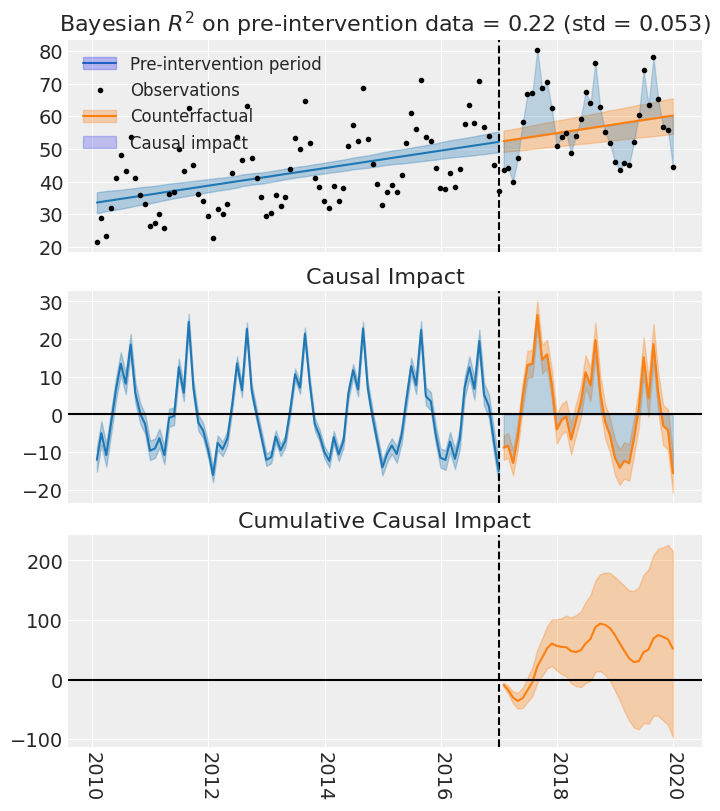

In [5]:
pipeline_result = cp.Pipeline(
    data=df,
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="y ~ 1 + t",
            model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": 42}),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(n_folds=2),
            ]
        ),
        cp.GenerateReport(include_plots=True),
    ],
).run()


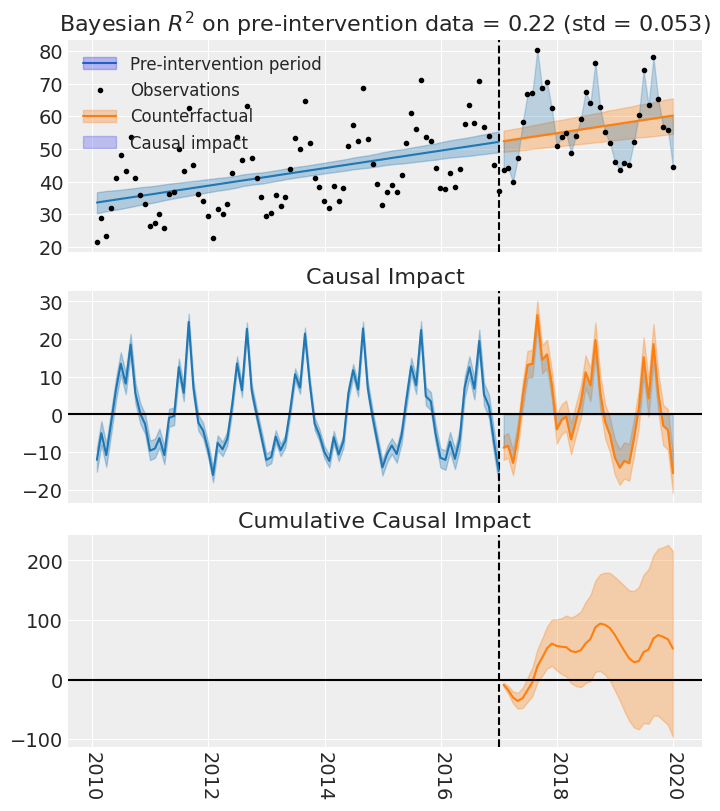
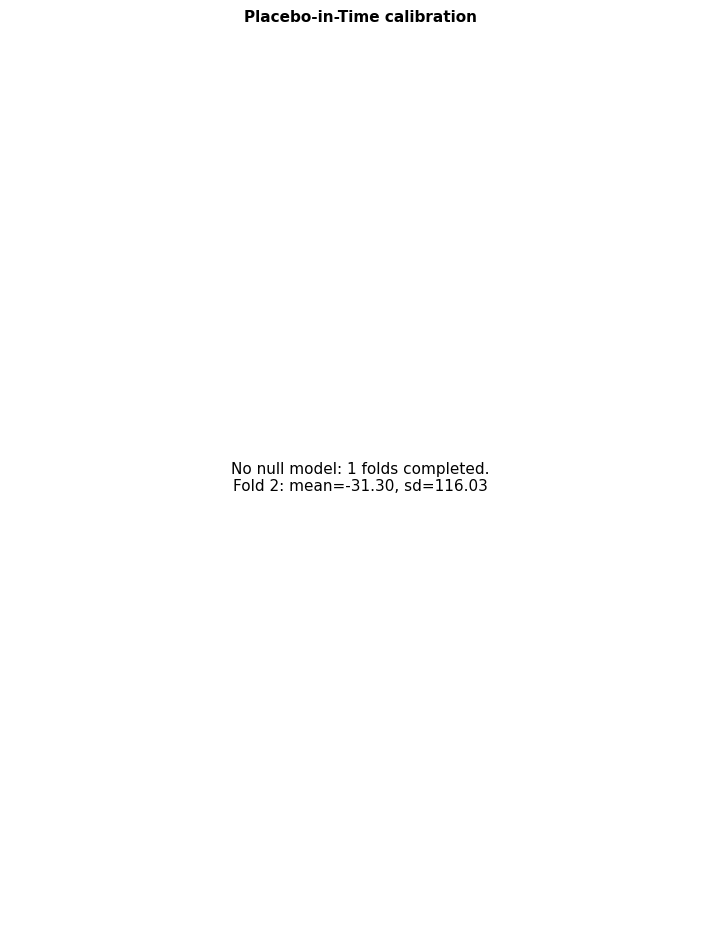

In [6]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", "Consider using IPython.display.IFrame", UserWarning
    )
    full_report = HTML(
        '<iframe srcdoc="'
        + html_module.escape(pipeline_result.report)
        + '" width="100%" height="1000"'
        ' style="border: 1px solid #ddd; border-radius: 6px;"></iframe>'
    )
full_report

## Saving to a file

Pass `output_file` to write the report to disk in a single call:

```python
result.generate_report(output_file="my_report.html")
```

Or save the returned string manually:

```python
from pathlib import Path

Path("my_report.html").write_text(html, encoding="utf-8")
```

:::{note}
When you use the {doc}`pipeline <pipeline-workflow>`, `GenerateReport`
can also include sensitivity-analysis results in the report. See the
pipeline notebook for that workflow.
:::